In [1]:

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, HMC
from IPython.core.pylabtools import figsize
import numpy as np
import pandas as pd

from pathlib import Path
import glob
from matplotlib import pyplot as plt
from scipy.stats.mstats import mquantiles
from sklearn.preprocessing import MinMaxScaler
from pyro.infer.autoguide import init_to_value


# Parameter determination for function
Data was obtained from a known function. Our goal is to identify the function parameters - here A and B. \
The function is a bi-lorentzian

## Set up function
Here we import the data, define a bi-Lorentzian function and demonstrate the impact of different values of center 1 and center 2 (A and B, respectively) on the simulated spectra.

In [2]:
temps_ = ['25', '30', '35',
       '40', '45', '50', '45', '40', '35', '30', '25', '20']
temps = np.array(temps_, dtype=float)

temps = temps + 273.15  # Convert to Kelvin

temps = torch.tensor(temps).double()

temps = temps[:6]  # Use only first 6 temps for training

temps_testing = temps[6:]  # Use last 6 temps for testing




In [3]:
len(temps)

6

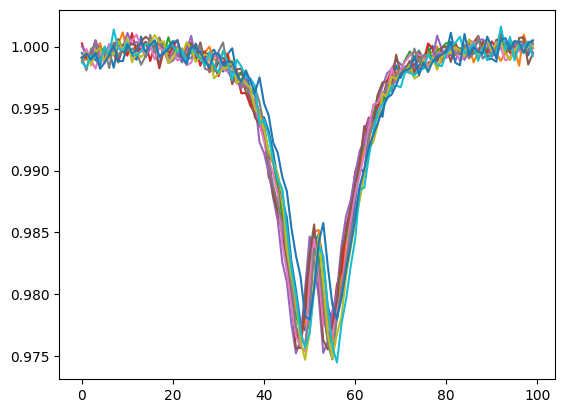

In [4]:
## import data file
fpath = './saved_data/cycle1'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, 1:-1]
df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', '-20'], inplace= True)
df.iloc[:, 2:].plot(legend= False)

# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr = df.iloc[:, 1:7]
y_esr_testing =  df.iloc[:, 7:]
#scale x axis to 0-100
sc = MinMaxScaler(feature_range=(0, 100))
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten()

torch.set_default_dtype(torch.float64)





In [5]:
df.shape

(100, 13)

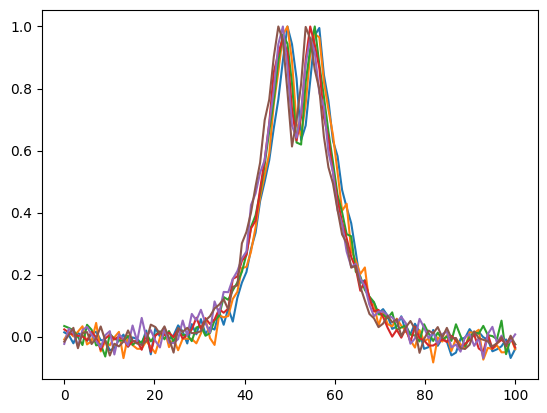

In [6]:
# plot baseline subtracted  y data
y_esr = y_esr.apply(lambda x: x - x[:10].mean())#+0.01
y_esr = -1*y_esr
y_esr = y_esr.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr);
#plt.xlim(40, 80)

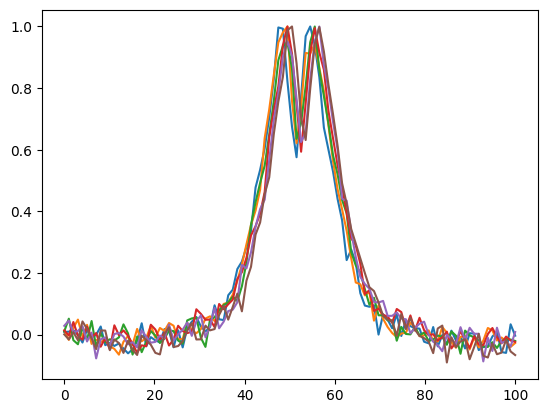

In [7]:
# plot baseline subtracted  y testing data
y_esr_testing = y_esr_testing.apply(lambda x: x - x[:10].mean())#+0.01
y_esr_testing = -1*y_esr_testing
y_esr_testing = y_esr_testing.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr_testing);

In [8]:
#numpy version of function
def F_np(x_in, Amp, alpha, beta, T):
    # Reshape A, B, Amp, G1, G2 for broadcasting with x_in
    alpha = alpha[None, :]
    Amp_reshaped = Amp[None, :]
    T_reshaped = T[None, :]
    beta = beta[None, :]
    A_reshaped = (T_reshaped*alpha) + beta # Shape (1, num_samples)
    X_reshaped = 8.420054307219287
    B_reshaped = A_reshaped + X_reshaped
     # Shape (1, num_samples)
    G1_reshaped = 7.9789 # New: Reshape gamma1
    G2_reshaped = 7.9789 # New: Reshape gamma2
    
    x_in_reshaped = x_in[:, None] # Shape (num_x_points, 1)

    F = (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - A_reshaped)**2 + (0.5 * G1_reshaped)**2) \
        + (Amp_reshaped) * (0.5 * G2_reshaped) / ((x_in_reshaped - B_reshaped)**2 + (0.5 * G2_reshaped)**2)
    return F


# A function to sample values of A and B and plot resulting function.
def F_samples():
    amp = pyro.sample("Amp", dist.Normal(0.95, 0.25))
    alpha = pyro.sample("alpha", dist.Normal(-71, 7.0)).double() /1000
    beta = pyro.sample("beta", dist.Normal(42., 10.0)) # Sample gamma1
    T_ = torch.tensor(273.15).double()
    T = T_ * np.ones_like(alpha) 
    A =  T*alpha + beta
    B =  A + 8.420054307219287
    gamma1 =  7.9789#pyro.sample("gamma1", dist.Normal(8.02, 1.0)).double()
    gamma2 = gamma1
    # Use the sampled gamma values in the function
    f_sim = lambda xi: (amp) *(0.5*gamma1)/((xi-A)**2 + (0.5*gamma1)**2) + (amp) *(0.5*gamma2)/((xi-B)**2 + (0.5*gamma2)**2)
    plt.plot(x_scale, f_sim(x_scale))
    # Update title to show sampled gamma values
    plt.title('A:' + str(A.numpy()) + ' B:' + str(B.numpy()) + ' G1:' + str(gamma1.numpy()) + ' G2:' + str(gamma2.numpy()))



## Define data we will start with and plot.

In [9]:

# this will be the data we'll start with, shown as red circles
def dataslicer(x, y, col1 =0 ,col2=1):
    x_scale_tensor = torch.tensor(x_scale).double()
    # squeeze the selected column to produce a 1-D tensor (N,) instead of (N,1)
    y_vals = y_esr.iloc[:, col1:col2].values.squeeze()
    y_scale_tensor = torch.tensor(y_vals).double()
    return x_scale_tensor, y_scale_tensor



(40.0, 70.0)

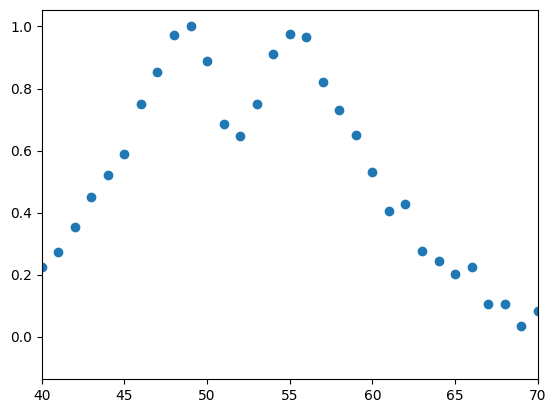

In [10]:
plt.plot(y_esr.iloc[:, 1].values, 'o')
plt.xlim(40,70)

## Set up and run Bayesian inference

In [11]:
# define the model
# Here we assume that we know the noise variance in the data = 0.1,
# though this can be set to another parameter to learn.

x_obs, y_obs = dataslicer(x_scale, y_esr, col1=0, col2=1)
T_ = 273.15 + 25.0  # Example temperature in Kelvin

data_ = (T_, (x_obs.clone().detach().double(), y_obs.clone().detach().double()))

def model(data_):
    T, data, = data_[0], data_[1]
    alpha = pyro.sample("alpha", dist.Normal(-0.077, 0.005)).double() 
    beta = pyro.sample("beta", dist.Normal(70., 10.0)) # Sample gamma1
    var = pyro.sample("var", dist.HalfNormal(scale=0.1)).double()
    gamma1 =  7.9789
    A =  T*alpha + beta
    B =  A + 8.420054307219287
    #gamma1 =  8.020510711744828 
    gamma2 = gamma1#pyro.sample("gamma2", dist.Normal(8.02, 1.0)).double()
    amp =  pyro.sample("amp", dist.Normal(3., 0.25 )).double()
    F =  (amp) * (0.5 * gamma1) / ((data[0] - A)**2 + (0.5 * gamma1)**2) \
        + (amp) * (0.5 * gamma2) / ((data[0] - B)**2 + (0.5 * gamma2)**2)
    
    # ensure F is a 1-D mean vector matching y_obs
    F = F.squeeze()

    #with pyro.plate("data", data[0].size(0)):
    pyro.sample("obs", dist.MultivariateNormal(F, var * torch.eye(data[1].shape[0]).double()), obs=data[1])

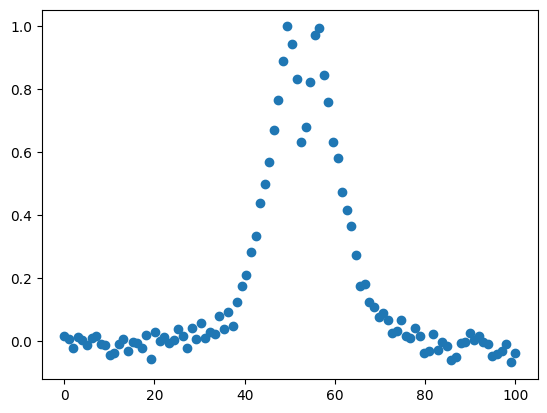

In [12]:
plt.plot(x_obs, y_obs, 'o')
#plt.xlim(40, 70)

In [13]:
temps = torch.tensor(temps).double()

C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_33320\2747252934.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temps = torch.tensor(temps).double()


In [14]:
# solve for the posterior using MCMC
# Use the observed x positions and y values as the data passed to the model


init_vals = {
    "alpha": torch.tensor(-0.077),
    "beta": torch.tensor(71.0),
    "gamma1": 7.9789,
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),}


kernel = NUTS(model, jit_compile=True, init_strategy=init_to_value(values=init_vals), max_tree_depth=9)
posterior = MCMC(kernel, num_samples=1000, warmup_steps=200, num_chains=1)
posterior.run((data_))



Sample: 100%|██████████| 1200/1200 [06:53,  2.90it/s, step size=2.74e-02, acc. prob=0.941]


#################


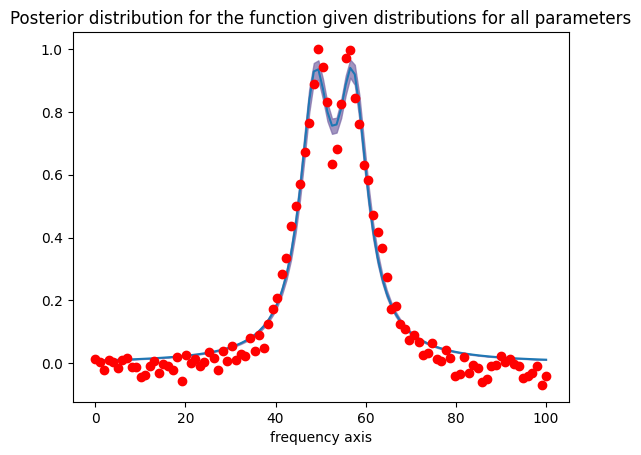

#################


In [15]:


hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
alpha = hmc_samples['alpha']
beta = hmc_samples['beta']
Amp = hmc_samples['amp'] # Get posterior samples for amp
var = hmc_samples['var'] # Get posterior samples for var
T = T_ * np.ones_like(alpha)  # Create T array matching alpha shape
F = F_np(x_scale, Amp, alpha, beta, T)
qs = mquantiles(F.T, [0.025, 0.975], axis=0)
F_mean = F.mean(axis = 1)

print('#################')
plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
plt.plot(x_scale, F_mean)
plt.plot(x_obs, y_obs, 'ro'); # plotting the data for this slice
plt.xlabel('frequency axis')
plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
pyro.clear_param_store()
print('#################')


In [16]:
print(f'alpha = {np.array(alpha).mean():.4f}')
print(f'alpha error = {np.array(alpha).var():.6f}')
print(f'beta = {np.array(beta).mean():.4f}')
print(f'beta error = {np.array(beta).var():.6f}')
print(f'amp = {np.array(hmc_samples["amp"]).mean():.4f}')
print(f'amp error = {np.array(hmc_samples["amp"]).var():.6f}')

alpha = -0.0766
alpha error = 0.000023
beta = 71.5911
beta error = 2.085231
amp = 3.1666
amp error = 0.002295


## Get results and plot

0
{'alpha': tensor(-0.0770), 'beta': tensor(71.), 'gamma1': 7.9789, 'amp': tensor(3.), 'var': tensor(0.0500)}


Warmup:   0%|          | 0/2200 [00:00, ?it/s]

Sample: 100%|██████████| 2200/2200 [09:24,  3.90it/s, step size=3.98e-02, acc. prob=0.930]

#################


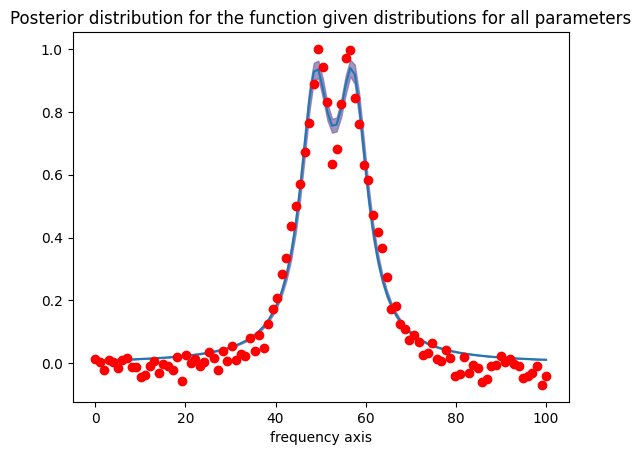

#################
1
{'alpha': tensor(-0.0771), 'beta': tensor(71.7475), 'amp': tensor(3.1656), 'var': tensor(0.0024)}


Sample: 100%|██████████| 2200/2200 [12:15,  2.99it/s, step size=3.63e-02, acc. prob=0.945]

#################


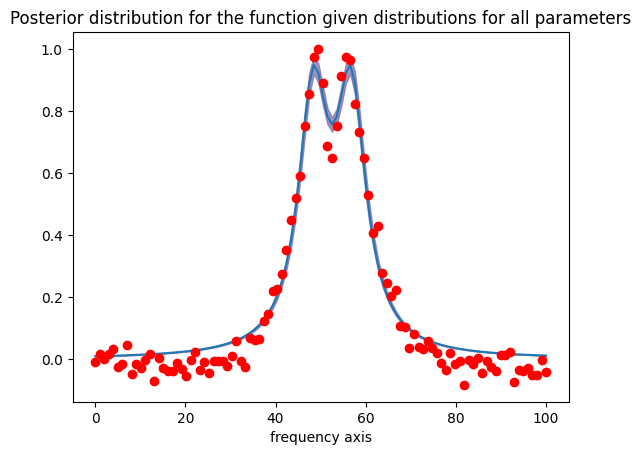

#################
2
{'alpha': tensor(-0.0771), 'beta': tensor(71.7118), 'amp': tensor(3.1895), 'var': tensor(0.0028)}


Sample: 100%|██████████| 2200/2200 [12:19,  2.97it/s, step size=2.62e-02, acc. prob=0.956]

#################


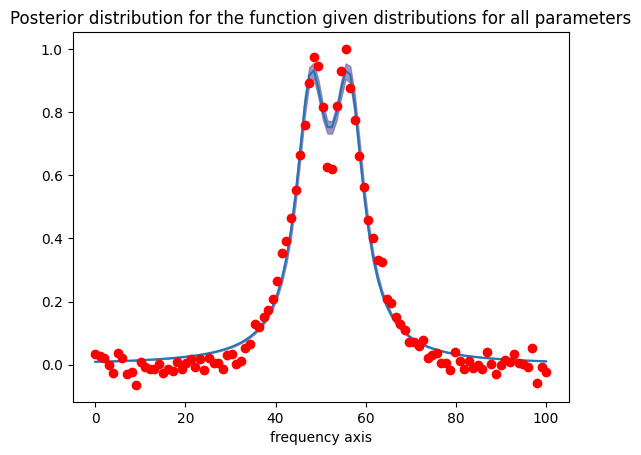

#################
3
{'alpha': tensor(-0.0768), 'beta': tensor(71.4924), 'amp': tensor(3.1442), 'var': tensor(0.0019)}


Sample: 100%|██████████| 2200/2200 [13:19,  2.75it/s, step size=2.71e-02, acc. prob=0.943]

#################


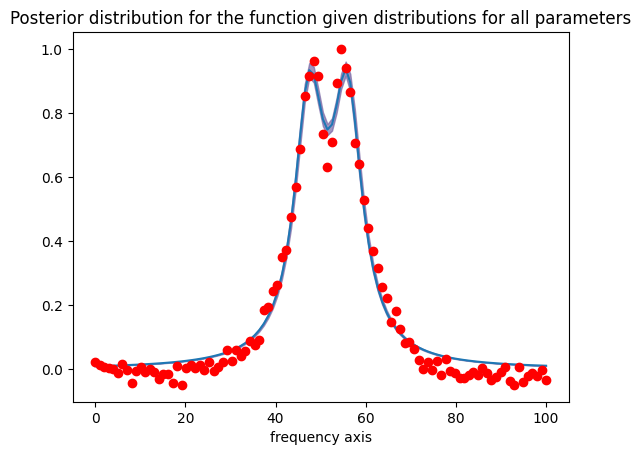

#################
4
{'alpha': tensor(-0.0765), 'beta': tensor(71.4492), 'amp': tensor(3.1501), 'var': tensor(0.0018)}


Sample: 100%|██████████| 2200/2200 [12:19,  2.97it/s, step size=3.09e-02, acc. prob=0.944]


#################


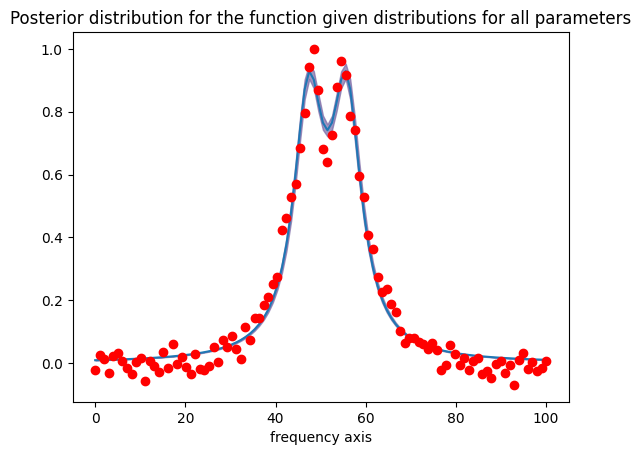

#################
5
{'alpha': tensor(-0.0770), 'beta': tensor(71.8036), 'amp': tensor(3.1238), 'var': tensor(0.0022)}


Sample: 100%|██████████| 2200/2200 [09:58,  3.67it/s, step size=3.21e-02, acc. prob=0.929]

#################


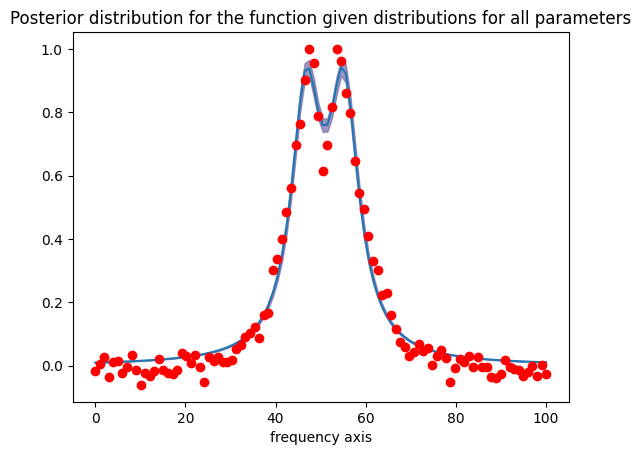

#################


In [17]:
idx = []
error_alpha = []
error_beta = []
alpha_, beta_, amp_ = [], [], []
beta_var, alpha_var,  amp_var = [], [], []

# init vals for MCMC

init_vals = {
    "alpha": torch.tensor(-0.077),
    "beta": torch.tensor(71.0),
    "gamma1": 7.9789,
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),}

alpha_arr = np.empty(y_esr.shape[1])
beta_arr = np.empty(y_esr.shape[1])
amp_arr = np.empty(y_esr.shape[1]) 
var_arr = np.empty(y_esr.shape[1])

for j in range(0, y_esr.shape[1]):
  print(j)
  print(init_vals)
  x_obs_j, y_obs_j = dataslicer(x_scale, y_esr, col1=j, col2=j+1)
  temps_j = temps[j]
  data_j_ = (temps_j, (x_obs_j[20:].clone().detach().double(), y_obs_j[20:].clone().detach().double()))
  kernel = NUTS(model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=9)
  posterior = MCMC(kernel, num_samples=2000, warmup_steps=200, num_chains=1)
  posterior.run(data_j_)
  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  alpha = hmc_samples['alpha']
  beta = hmc_samples['beta']
  Amp = hmc_samples['amp'] # Get posterior samples for amp
  var = hmc_samples['var'] # Get posterior samples for var
  T = temps_j.item() * np.ones_like(alpha)  # Create T array matching alpha shape
  var = hmc_samples['var'] # Get posterior samples for var
  F = F_np(x_scale, Amp, alpha, beta, T)
  qs = mquantiles(F.T, [0.025, 0.975], axis=0)
  F_mean = F.mean(axis = 1)
  idx.append(j)
  amp_.append(Amp.mean())  
  alpha_.append(alpha.mean())
  beta_.append(beta.mean())
  alpha_var.append(alpha.var())
  beta_var.append(beta.var())
  amp_var.append(Amp.var())

  print('#################')
  plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
  plt.plot(x_scale, F_mean)
  plt.plot(x_obs_j, y_obs_j, 'ro'); # plotting the data for this slice
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  #pyro.clear_param_store()
  init_vals = {
      "alpha": torch.tensor(alpha.mean()),
      "beta": torch.tensor(beta.mean()),
      "amp": torch.tensor(Amp.mean()),
      "var": torch.tensor(var.mean()),}    
  print('#################')


In [18]:
print(f'alpha = {np.array(alpha_).mean():.4f}')
print(f'alpha error = {np.array(alpha_var).mean():.6f}')

print(f'beta = {np.array(beta_).mean():.4f}')
print(f'beta error = {np.array(beta_var).mean():.6f}')

alpha = -0.0769
alpha error = 0.000025
beta = 71.6426
beta error = 2.382133


In [ ]:
### define the calibrated model, use learned posterior distribution as input to the claibrated model
## when alpha and beta are fixed the posterior sigma in T is around 2.3 K

def calibrated_model(data_):
    data = data_
    alpha = pyro.sample("alpha", dist.Normal(np.array(alpha_).mean(), 0.0001 ))
    # Sample beta from a narrow Normal centered on the learned mean (avoid passing a raw float)
    beta_mean = np.array(beta_).mean()
    beta_var_mean = np.array(beta_var).mean() if len(beta_var) > 0 else 1e-6
    beta = pyro.sample("beta", dist.Normal(beta_mean, np.sqrt(beta_var_mean + 1e-8)))
    var = pyro.sample("var", dist.HalfNormal(scale=0.1))
    gamma1 = 7.9789
    T = pyro.sample("T", dist.Uniform(242, 343))
    A =  T*alpha + beta
    B =  A + 8.420054307219287
    gamma2 = gamma1#pyro.sample("gamma2", dist.Normal(8.02, 1.0)).double()
    amp =  pyro.sample("amp", dist.Normal(1.25, 0.25 ))
    F =  (amp) * (0.5 * gamma1) / ((data[0] - A)**2 + (0.5 * gamma1)**2) \
        + (amp) * (0.5 * gamma2) / ((data[0] - B)**2 + (0.5 * gamma2)**2)
    
    # ensure F is a 1-D mean vector matching y_obs
    F = F.squeeze()

    #with pyro.plate("data", data[0].size(0)):
    pyro.sample("obs", dist.MultivariateNormal(F, var * torch.eye(data[1].shape[0]).double()), obs=data[1])

In [25]:
#numpy version of function
def F_np_calibrated(x_in, Amp, gamma, T):
    # Ensure Amp, gamma, T are array-like so scalars work
    Amp = np.atleast_1d(Amp)
    gamma = np.atleast_1d(gamma)
    T = np.atleast_1d(T)

    # Reshape A, B, Amp, G1, G2 for broadcasting with x_in
    alpha = np.array(alpha_).mean()
    Amp_reshaped = Amp[None, :]
    T_reshaped = T[None, :]
    beta = np.array(beta_).mean()
    A_reshaped = (T_reshaped*alpha) + beta # Shape (1, num_samples)
    X_reshaped = 8.420054307219287
    B_reshaped = A_reshaped + X_reshaped
     # Shape (1, num_samples)
    G1_reshaped = gamma[None, :] # New: Reshape gamma1
    G2_reshaped = gamma[None, :] # New: Reshape gamma2

    x_in_reshaped = x_in[:, None] # Shape (num_x_points, 1)

    F = (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - A_reshaped)**2 + (0.5 * G1_reshaped)**2) \
        + (Amp_reshaped) * (0.5 * G2_reshaped) / ((x_in_reshaped - B_reshaped)**2 + (0.5 * G2_reshaped)**2)
    return F


# A function to sample values of A and B and plot resulting function.
def F_calibrated_samples():
    alpha = torch.tensor(np.array(alpha_).mean())
    beta = torch.tensor(np.array(beta_).mean())
    var = pyro.sample("var", dist.HalfNormal(scale=0.1))
    T = pyro.sample("T", dist.Uniform(242, 343)) * torch.ones_like(alpha)
    gamma1 =  7.9789
    A =  T*alpha + beta
    B =  A + 8.420054307219287
    gamma2 = gamma1#pyro.sample("gamma2", dist.Normal(8.02, 1.0))
    amp =  pyro.sample("amp", dist.Normal(1.25, 0.25 ))
    
    f_sim = lambda xi: (amp) *(0.5*gamma1)/((xi-A)**2 + (0.5*gamma1)**2) + (amp) *(0.5*gamma2)/((xi-B)**2 + (0.5*gamma2)**2)
    plt.plot(x_scale, f_sim(x_scale))
    # Update title to show sampled gamma values
    plt.title('A:' + str(A.numpy()) + ' B:' + str(B.numpy()) + ' G1:' + str(gamma1.numpy()) + ' G2:' + str(gamma2.numpy()))

0


Sample: 100%|██████████| 5500/5500 [15:14,  6.01it/s, step size=3.36e-02, acc. prob=0.939]

#################
experimental temperature: 298.15 K, inferred temperature: 297.33 K


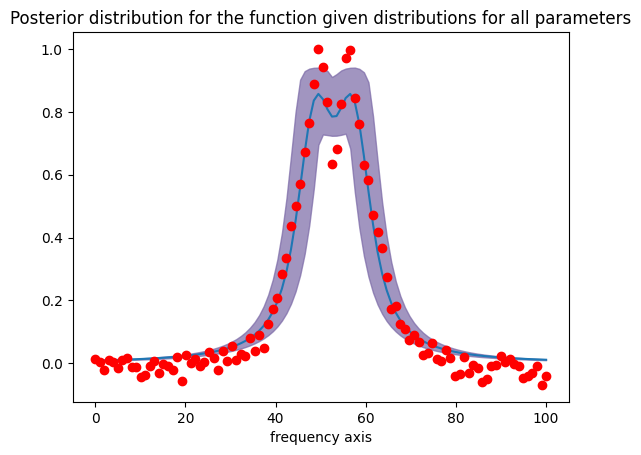

#################
1


Sample: 100%|██████████| 5500/5500 [14:07,  6.49it/s, step size=4.68e-02, acc. prob=0.906]

#################
experimental temperature: 303.15 K, inferred temperature: 302.29 K


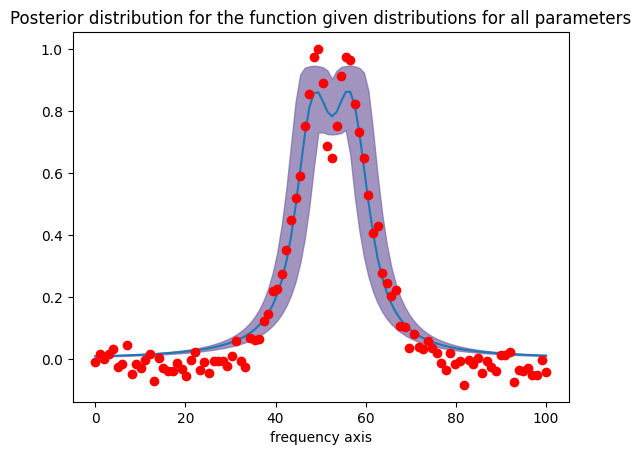

#################
2


Sample: 100%|██████████| 5500/5500 [14:57,  6.13it/s, step size=4.61e-02, acc. prob=0.944]

#################
experimental temperature: 308.15 K, inferred temperature: 307.27 K


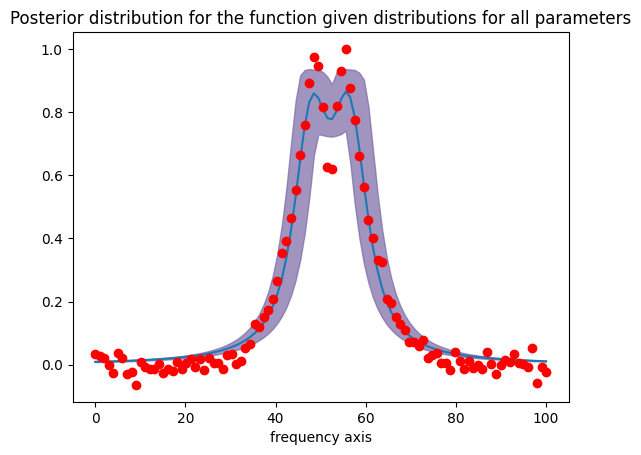

#################
3


Sample: 100%|██████████| 5500/5500 [15:25,  5.94it/s, step size=4.97e-02, acc. prob=0.958]

#################
experimental temperature: 313.15 K, inferred temperature: 308.99 K


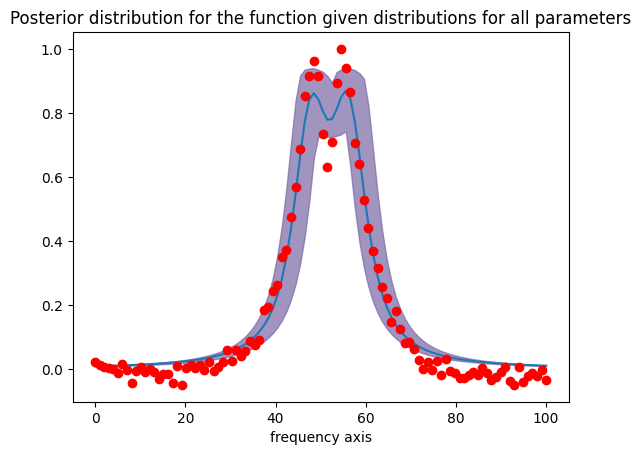

#################
4


Sample: 100%|██████████| 5500/5500 [14:46,  6.20it/s, step size=4.26e-02, acc. prob=0.933]

#################
experimental temperature: 318.15 K, inferred temperature: 312.16 K


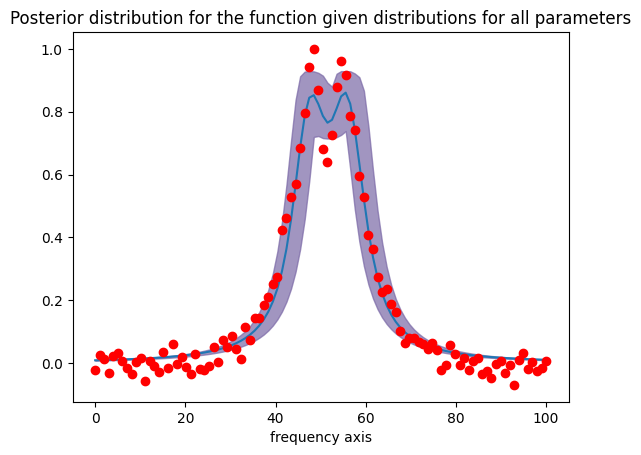

#################
5


Sample: 100%|██████████| 5500/5500 [15:05,  6.07it/s, step size=3.76e-02, acc. prob=0.954]

#################
experimental temperature: 323.15 K, inferred temperature: 316.24 K


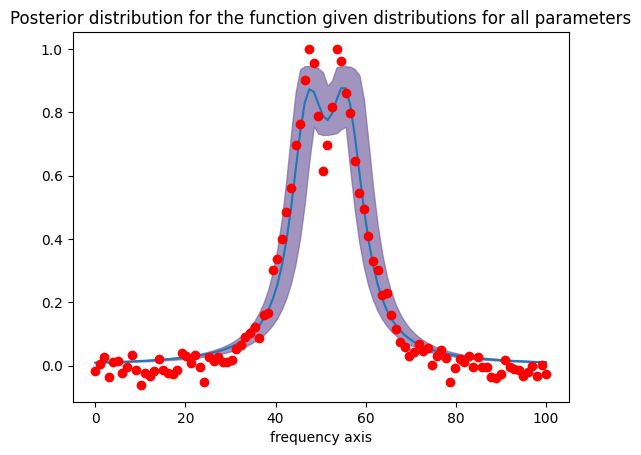

#################


In [30]:
idx = []
error_alpha = []
temp_, amp_ = [], []
alpha_var, amp_var = [], []
temp_var = []
temp_var = []
temp_ci_high, temp_ci_low = [], []
# init vals for MCMC
gamma = 7.9789
init_vals = {
    "T": torch.tensor(300.),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05)}


for j in range(0, y_esr.shape[1]):
  print(j)
  x_obs_j, y_obs_j = dataslicer(x_scale, y_esr, col1=j, col2=j+1)
  temps_j = temps[j]
  data_j = (x_obs_j[20:].clone().detach().double(), y_obs_j[20:].clone().detach().double())
  kernel = NUTS(calibrated_model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=6)
  posterior = MCMC(kernel, num_samples=5000, warmup_steps=500, num_chains=1)
  posterior.run(data_j)
  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  T = hmc_samples['T']
  Amp = hmc_samples['amp'] # Get posterior samples for amp
  var = hmc_samples['var'] # Get posterior samples for var
  var = hmc_samples['var'] # Get posterior samples for var
  F = F_np_calibrated(x_scale, Amp, gamma, T)
  qs = mquantiles(F.T, [0.025, 0.975], axis=0)
  F_mean = F.mean(axis = 1)
  idx.append(j)
  amp_.append(Amp.mean())  
  temp_.append(T.mean())
  temp_var.append(T.var())
  amp_var.append(Amp.var())
  T_ci = np.quantile(T, [0.025, 0.975])
  temp_ci_low.append(T_ci[0])
  temp_ci_high.append(T_ci[1])
  print('#################')
  print(f'experimental temperature: {temps_j.item():.2f} K, inferred temperature: {T.mean():.2f} K')
  plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
  plt.plot(x_scale, F_mean)
  plt.plot(x_obs_j, y_obs_j, 'ro'); # plotting the data for this slice
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  #pyro.clear_param_store()
  init_vals = {
      "T": torch.tensor(T.mean()),
      "amp": torch.tensor(Amp.mean()),
      "var": torch.tensor(var.mean()),}    
  print('#################')

In [31]:
print(f'amp = {np.array(amp_).mean():.4f}')
print(f'amp error = {np.array(amp_var).mean():.6f}')

print(f'Temperature = {np.array(temp_).mean():.2f} K')
print(f'Temperature error = {np.array(temp_var).mean():.6f}')

amp = 3.1042
amp error = 0.002003
Temperature = 307.38 K
Temperature error = 327.680586


C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_33320\789146927.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(np.array(temps[:]), 'ro--')


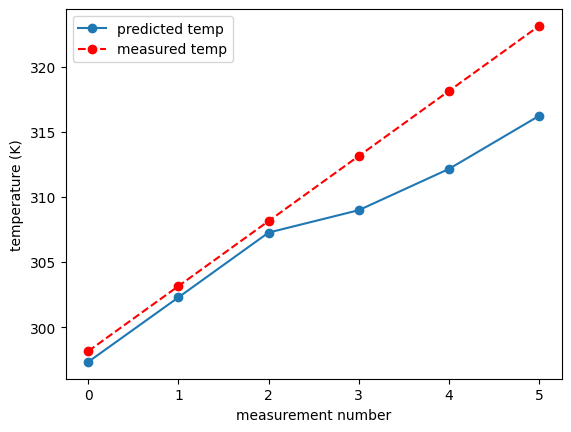

In [32]:
temperature = np.array(temp_)
plt.plot(temperature, 'o-')
plt.plot(np.array(temps[:]), 'ro--')
plt.xlabel('measurement number')
plt.ylabel('temperature (K)')
plt.legend(['predicted temp', 'measured temp'])

C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_33320\647111144.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(np.array(temps[:]), temperature, 'bo')
C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_33320\647111144.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sns.regplot(x = np.array(temps[:]), y = temperature)


<Axes: xlabel='Experimental Temperature (K)', ylabel='Inferred Temperature (K)'>

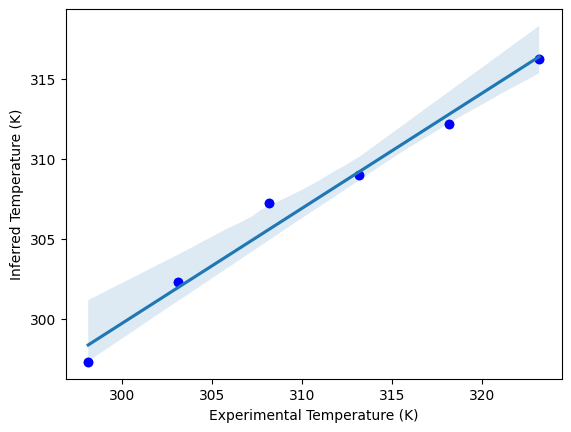

In [33]:
# plt.plot(np.array(temps[1:]), temperature, 'r--')
plt.plot(np.array(temps[:]), temperature, 'bo')
plt.xlabel('Experimental Temperature (K)')
plt.ylabel('Inferred Temperature (K)')
import seaborn as sns
sns.regplot(x = np.array(temps[:]), y = temperature)

In [34]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(np.array(temps[:]) , temperature)

C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_33320\2884708818.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  root_mean_squared_error(np.array(temps[:]) , temperature)


4.146893002831572

C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_33320\302759175.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(np.array(temps), np.array(temp_), 'bo')


Text(0, 0.5, 'Inferred Temperature (K)')

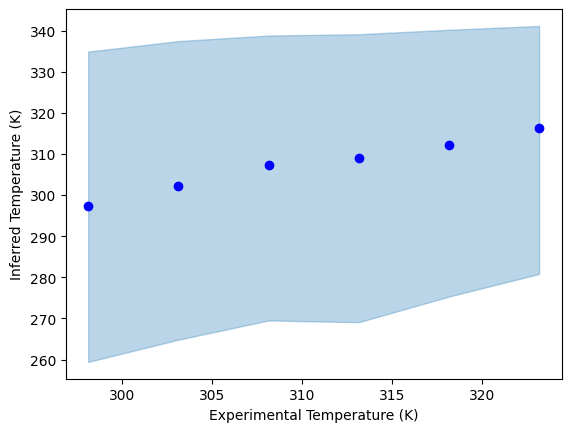

In [35]:
from scipy import stats


plt.plot(np.array(temps), np.array(temp_), 'bo')
plt.fill_between(temps, temp_ci_low, temp_ci_high, alpha=0.3, color='C0', label='k=1')
plt.xlabel('Experimental Temperature (K)')
plt.ylabel('Inferred Temperature (K)')

## Redo Calibration loop but now with moving average

0
{'alpha': tensor(-0.0770), 'beta': tensor(71.), 'amp': tensor(3.), 'var': tensor(0.0500)}


Sample: 100%|██████████| 5200/5200 [23:59,  3.61it/s, step size=3.51e-02, acc. prob=0.932]

#################


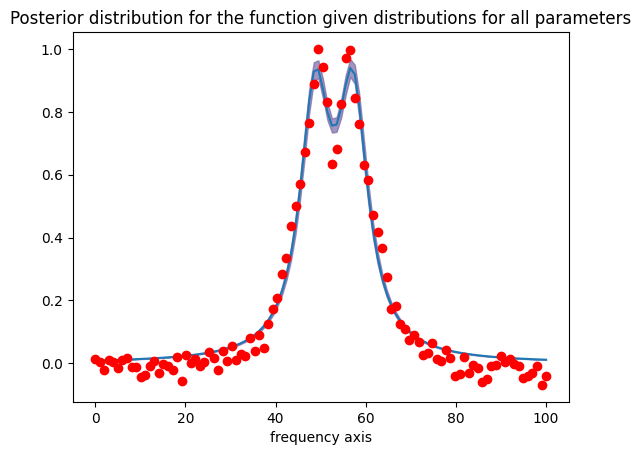

#################
1
{'alpha': tensor(-0.0768), 'beta': tensor(71.6324), 'amp': tensor(3.1661), 'var': tensor(0.0024)}


Sample: 100%|██████████| 5200/5200 [27:46,  3.12it/s, step size=3.69e-02, acc. prob=0.937]

#################


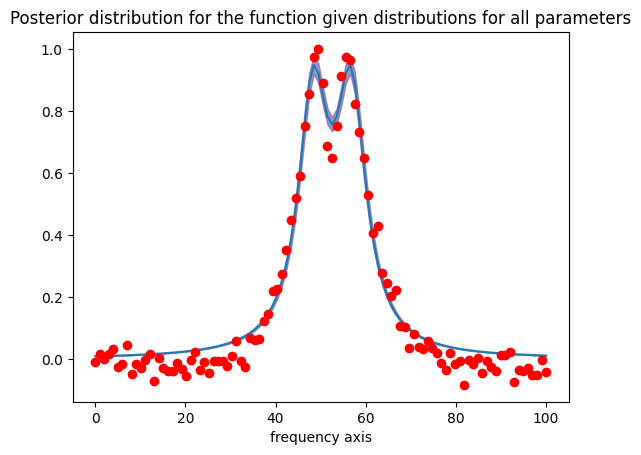

#################
2
{'alpha': tensor(-0.0769), 'beta': tensor(71.6574), 'amp': tensor(3.1894), 'var': tensor(0.0028)}


Sample: 100%|██████████| 5200/5200 [30:17,  2.86it/s, step size=2.90e-02, acc. prob=0.938]

#################


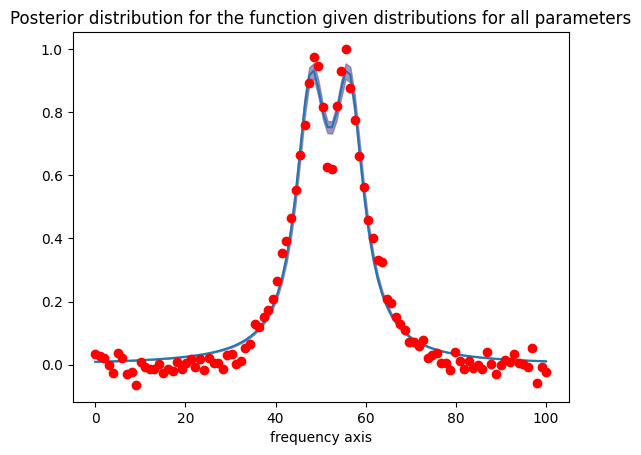

#################
3
{'alpha': tensor(1.9230), 'beta': tensor(44.9403), 'amp': tensor(2.2998), 'var': tensor(0.0014)}


Sample: 100%|██████████| 5200/5200 [03:22, 25.69it/s, step size=3.23e-01, acc. prob=0.931]


#################


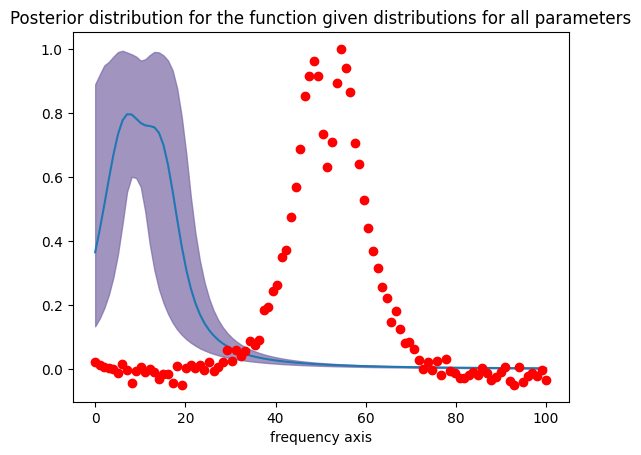

#################
4
{'alpha': tensor(1.0612), 'beta': tensor(50.1931), 'amp': tensor(2.6976), 'var': tensor(0.0298)}


Sample: 100%|██████████| 5200/5200 [25:51,  3.35it/s, step size=2.61e-02, acc. prob=0.957]

#################


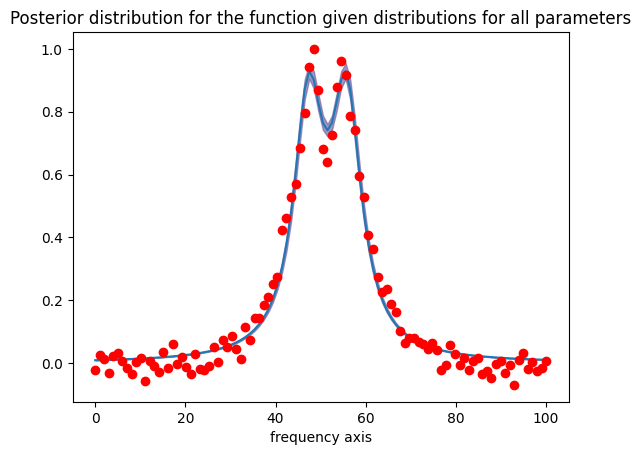

#################
5
{'alpha': tensor(-0.0775), 'beta': tensor(63.4153), 'amp': tensor(3.1222), 'var': tensor(0.0302)}


Sample: 100%|██████████| 5200/5200 [27:58,  3.10it/s, step size=2.53e-02, acc. prob=0.936]


#################


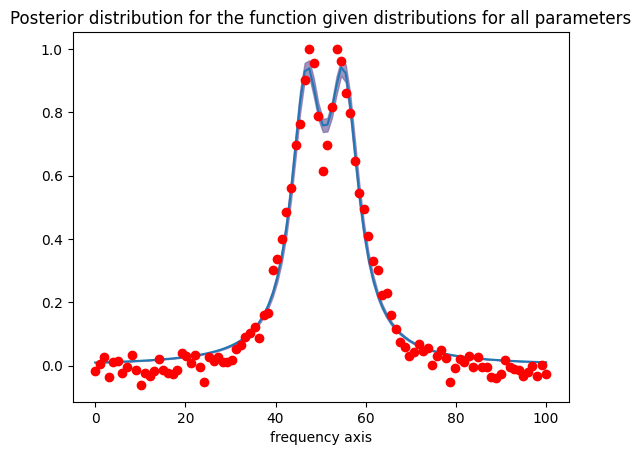

#################


In [36]:
idx = []
error_alpha = []
error_beta = []
alpha_, beta_, amp_ = [], [], []
beta_var, alpha_var, amp_var = [], [], []

# init vals for MCMC

init_vals = {
    "alpha": torch.tensor(-0.077),
    "beta": torch.tensor(71.0),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),}

alpha_arr = np.empty(y_esr.shape[1],)
beta_arr = np.empty(y_esr.shape[1],)
amp_arr = np.empty(y_esr.shape[1],) 
var_arr = np.empty(y_esr.shape[1],)


for j in range(0, y_esr.shape[1]):
  print(j)
  print(init_vals)
  x_obs_j, y_obs_j = dataslicer(x_scale, y_esr, col1=j, col2=j+1)
  temps_j = temps[j]
  data_j_ = (temps_j, (x_obs_j[20:].clone().detach().double(), y_obs_j[20:].clone().detach().double()))
  kernel = NUTS(model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=12)
  posterior = MCMC(kernel, num_samples=5000, warmup_steps=200, num_chains=1)
  posterior.run(data_j_)
  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  alpha = hmc_samples['alpha']
  beta = hmc_samples['beta']
  Amp = hmc_samples['amp'] # Get posterior samples for amp
  var = hmc_samples['var'] # Get posterior samples for var
  T = temps_j.item() * np.ones_like(alpha)  # Create T array matching alpha shape
  var = hmc_samples['var'] # Get posterior samples for var
  F = F_np(x_scale, Amp, alpha, beta, T)
  qs = mquantiles(F.T, [0.025, 0.975], axis=0)
  F_mean = F.mean(axis = 1)
  idx.append(j)
  amp_.append(Amp.mean())  
  alpha_.append(alpha.mean())
  beta_.append(beta.mean())
  alpha_var.append(alpha.var())
  beta_var.append(beta.var())
  amp_var.append(Amp.var())
  alpha_arr[j] = alpha.mean()
  beta_arr[j] = beta.mean()
  var_arr[j] = var.mean()
  amp_arr[j] = Amp.mean()

  print('#################')
  plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
  plt.plot(x_scale, F_mean)
  plt.plot(x_obs_j, y_obs_j, 'ro'); # plotting the data for this slice
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  #pyro.clear_param_store()
  if j < 2:
    init_vals = {
      "alpha": torch.tensor(alpha.mean()),
      "beta": torch.tensor(beta.mean()),
      "amp": torch.tensor(Amp.mean()),
      "var": torch.tensor(var.mean()),}    
  else:
    init_vals = {
        "alpha": torch.tensor(alpha_arr[:-1].mean()),
        "beta": torch.tensor(beta_arr[:-1].mean()),
        "amp": torch.tensor(amp_arr[:-1].mean()),
        "var": torch.tensor(var_arr[:-1].mean()) }
  print('#################')


In [37]:
alpha_arr

array([-0.076764  , -0.07692974, -0.07678917, -0.08000336, -0.07698119,
       -0.07693585])

Warmup:   0%|          | 0/1200 [4:14:24, ?it/s]


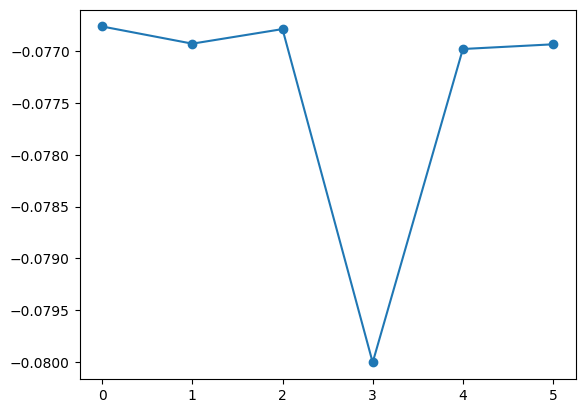

In [38]:
plt.plot(alpha_arr, 'o-')

0


Sample: 100%|██████████| 2200/2200 [05:38,  6.50it/s, step size=1.59e-02, acc. prob=0.906]

#################
experimental temperature: 298.15 K, inferred temperature: 254.75 K


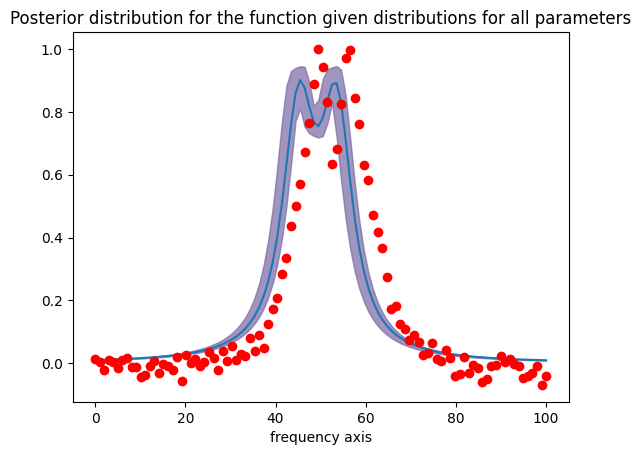

#################
1


Sample: 100%|██████████| 2200/2200 [06:04,  6.04it/s, step size=1.80e-02, acc. prob=0.873]

#################
experimental temperature: 303.15 K, inferred temperature: 262.51 K


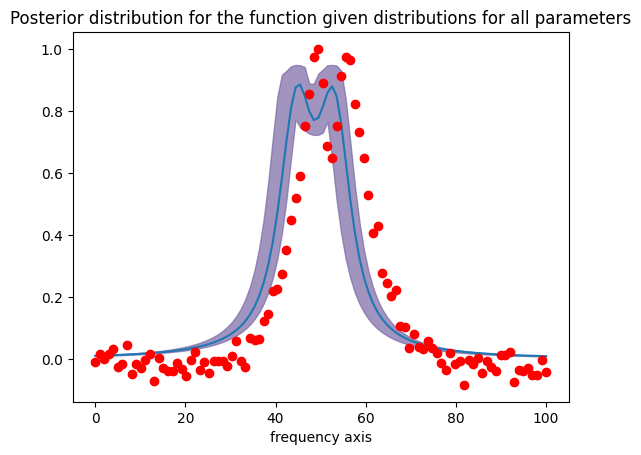

#################
2


Sample: 100%|██████████| 2200/2200 [05:52,  6.24it/s, step size=1.60e-02, acc. prob=0.843]

#################
experimental temperature: 308.15 K, inferred temperature: 256.71 K


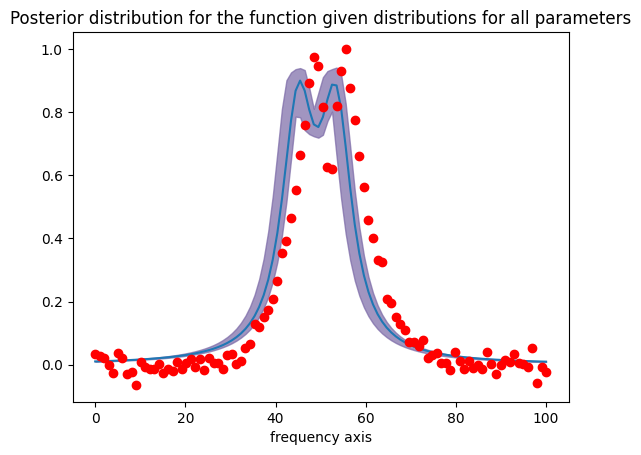

#################
3


Sample: 100%|██████████| 2200/2200 [05:37,  6.51it/s, step size=1.66e-02, acc. prob=0.934]


#################
experimental temperature: 313.15 K, inferred temperature: 258.34 K


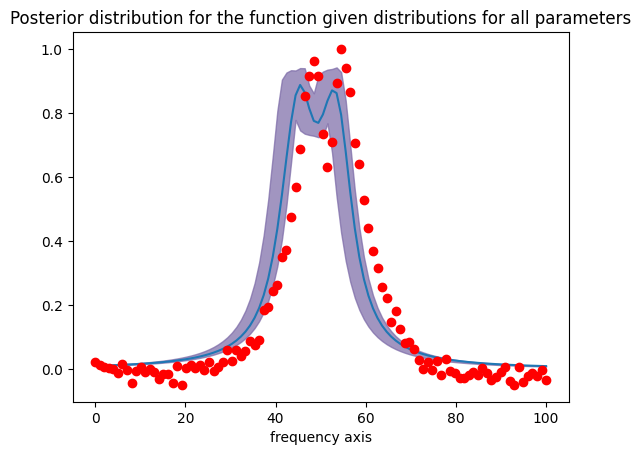

#################
4


Sample: 100%|██████████| 2200/2200 [05:29,  6.68it/s, step size=2.31e-02, acc. prob=0.949]

#################
experimental temperature: 318.15 K, inferred temperature: 260.73 K


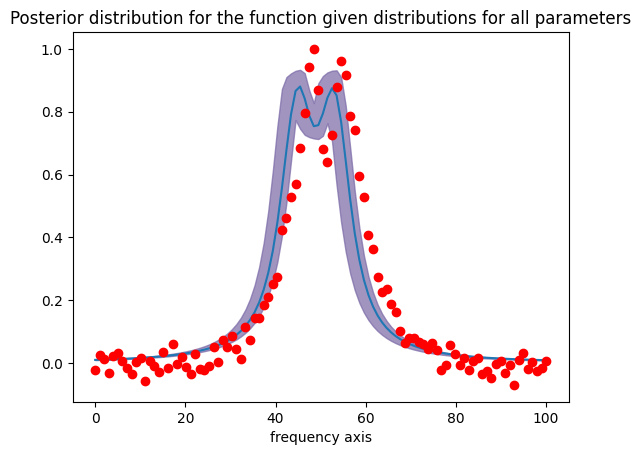

#################
5


Sample: 100%|██████████| 2200/2200 [06:39,  5.51it/s, step size=7.53e-03, acc. prob=0.844]


#################
experimental temperature: 323.15 K, inferred temperature: 264.44 K


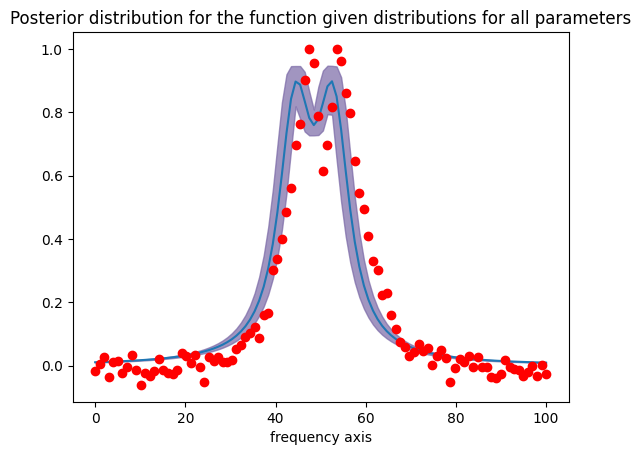

#################


In [40]:
idx = []
temp_, amp_ = [], []
amp_var = []
temp_var = []
temp_ci_high, temp_ci_low = [], []

gamma = 7.9789

# init vals for MCMC

init_vals = {
    "T": torch.tensor(300.),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),}


for j in range(0, y_esr.shape[1]):
  print(j)
  x_obs_j, y_obs_j = dataslicer(x_scale, y_esr, col1=j, col2=j+1)
  temps_j = temps[j]
  data_j = (x_obs_j[20:].clone().detach().double(), y_obs_j[20:].clone().detach().double())
  kernel = NUTS(calibrated_model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=6)
  posterior = MCMC(kernel, num_samples=2000, warmup_steps=200, num_chains=1)
  posterior.run(data_j)
  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  T = hmc_samples['T']
  Amp = hmc_samples['amp'] # Get posterior samples for amp
  var = hmc_samples['var'] # Get posterior samples for var
  var = hmc_samples['var'] # Get posterior samples for var
  F = F_np_calibrated(x_scale, Amp, gamma, T)
  qs = mquantiles(F.T, [0.025, 0.975], axis=0)
  F_mean = F.mean(axis = 1)
  idx.append(j)
  amp_.append(Amp.mean())  
  temp_.append(T.mean())
  temp_var.append(T.var())
  #gamma1_var.append(gamma1_.var())
  amp_var.append(Amp.var())
  T_ci = np.quantile(T, [0.025, 0.975])
  temp_ci_low.append(T_ci[0])
  temp_ci_high.append(T_ci[1])
  print('#################')
  print(f'experimental temperature: {temps_j.item():.2f} K, inferred temperature: {T.mean():.2f} K')
  plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
  plt.plot(x_scale, F_mean)
  plt.plot(x_obs_j, y_obs_j, 'ro'); # plotting the data for this slice
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  #pyro.clear_param_store()
#   init_vals = {
#       "T": torch.tensor(T.mean()),
#       "gamma1": torch.tensor(gamma1_.mean()),
#       "amp": torch.tensor(Amp.mean()),
#       "var": torch.tensor(var.mean()),}    
  print('#################')

In [41]:
print(f'amp = {np.array(amp_).mean():.4f}')
print(f'amp error = {np.array(amp_var).mean():.6f}')


print(f'Temperature = {np.array(temp_).mean():.2f} K')
print(f'Temperature error = {np.array(temp_var).mean():.6f}')



amp = 3.1045
amp error = 0.001990
Temperature = 259.58 K
Temperature error = 171.631153
